In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_movies.csv
/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_credits.csv


# Movie Recommender System (Content-Based)
Recommends similar movies using TMDB metadata (genres, cast, crew, overview) 
via weighted tags → CountVectorizer/SBERT embeddings → cosine similarity.
See README for full write-up.

In [2]:
movies=pd.read_csv('/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_movies.csv')
credits=pd.read_csv('/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_credits.csv')

In [3]:
movies.sample(10)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
163,130000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 9648, ""n...",https://www.warnerbros.com/watchmen,13183,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 1308...",en,Watchmen,In a gritty and alternate 1985 the glory days ...,64.798873,"[{""name"": ""Paramount Pictures"", ""id"": 4}, {""na...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-03-05,185258983,163.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Justice is coming to all of us. No matter wha...,Watchmen,7.0,2811
2597,0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 35, ""nam...",NaN,10743,"[{""id"": 159607, ""name"": ""grifter""}, {""id"": 159...",en,Confidence,What Jake Vig doesn't know just might get him ...,9.874190,"[{""name"": ""Cinerenta Medienbeteiligungs KG"", ""...","[{""iso_3166_1"": ""CA"", ""name"": ""Canada""}, {""iso...",2003-04-25,0,97.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,It's not about the money. It's about the money.,Confidence,6.4,126
2872,12000000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10749, ""...",NaN,31246,"[{""id"": 4344, ""name"": ""musical""}]",en,From Justin to Kelly,"A lonely, sexually repressed man. A depressed ...",1.623338,"[{""name"": ""19 Entertainment"", ""id"": 20877}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2003-06-20,4922166,90.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The tale of two American Idols.,From Justin to Kelly,3.0,23
29,200000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.skyfall-movie.com,37724,"[{""id"": 470, ""name"": ""spy""}, {""id"": 4289, ""nam...",en,Skyfall,When Bond's latest assignment goes gravely wro...,93.004993,"[{""name"": ""Columbia Pictures"", ""id"": 5}]","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2012-10-25,1108561013,143.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Think on your sins.,Skyfall,6.9,7604
2869,12000000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",NaN,14799,[],en,For Your Consideration,Three actors learn that their respective perfo...,4.330428,"[{""name"": ""Shangri-La Entertainment"", ""id"": 22...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2006-11-22,5542025,86.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,For Your Consideration,5.9,43
683,62000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",NaN,12138,"[{""id"": 585, ""name"": ""casino""}, {""id"": 1375, ""...",en,3000 Miles to Graceland,It was an ingenious enough plan: rob the Rivie...,11.262655,"[{""name"": ""Franchise Pictures"", ""id"": 1403}, {...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2001-02-23,18720175,125.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Crime Is King.,3000 Miles to Graceland,5.8,178
488,86000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",NaN,9992,"[{""id"": 1158, ""name"": ""grandfather grandson re...",en,Arthur et les Minimoys,Arthur is a spirited ten-year old whose parent...,27.097932,"[{""name"": ""Canal Plus"", ""id"": 104}, {""name"": ""...","[{""iso_3166_1"": ""FR"", ""name"": ""France""}]",2006-12-13,107944236,94.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Adventure awaits in your own backyard.,Arthur and the Invisibles,6.0,639
3237,8000000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 14, ""nam...",NaN,2619,"[{""id"": 1338, ""name"": ""bachelor""}, {""id"": 5938...",en,Splash,A successful businessman falls in love with th...,21.735068,"[{""name"": ""Touchstone Pictures"", ""id"": 9195}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",1984-03-09,69821334,111.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Allen Bauer Thought He'd Never F

In [4]:
credits.sample(5)

,movie_id,title,cast,crew
4636,44490,Chuck & Buck,"[{""cast_id"": 1, ""character"": ""Buck O'Brien"", ""...","[{""credit_id"": ""53463de60e0a265fe6000f2b"", ""de..."
3306,389425,Code of Honor,"[{""cast_id"": 0, ""character"": ""Robert Sikes"", ""...","[{""credit_id"": ""57568aafc3a36859ed000640"", ""de..."
4769,69382,The Legend of God's Gun,"[{""cast_id"": 1001, ""character"": ""The Gunslinge...","[{""credit_id"": ""52fe47c5c3a368484e0d89cf"", ""de..."
1625,9271,Virtuosity,"[{""cast_id"": 10, ""character"": ""Lt. Parker Barn...","[{""credit_id"": ""52fe44dfc3a36847f80af169"", ""de..."
2709,245700,Mr. Turner,"[{""cast_id"": 4, ""character"": ""JMW Turner"", ""cr...","[{""credit_id"": ""58f56ad4c3a3680e50005f41"", ""de..."


In [5]:
credits.sample(1)['cast'].values

array(['[{"cast_id": 6, "character": "Rick Deckard", "credit_id": "52fe4214c3a36847f800259f", "gender": 2, "id": 3, "name": "Harrison Ford", "order": 0}, {"cast_id": 7, "character": "Roy Batty", "credit_id": "52fe4214c3a36847f80025a3", "gender": 2, "id": 585, "name": "Rutger Hauer", "order": 1}, {"cast_id": 8, "character": "Rachael", "credit_id": "52fe4214c3a36847f80025a7", "gender": 1, "id": 586, "name": "Sean Young", "order": 2}, {"cast_id": 9, "character": "Gaff", "credit_id": "52fe4214c3a36847f80025ab", "gender": 2, "id": 587, "name": "Edward James Olmos", "order": 3}, {"cast_id": 42, "character": "Bryant", "credit_id": "5402bd1bc3a3684360004649", "gender": 2, "id": 588, "name": "M. Emmet Walsh", "order": 4}, {"cast_id": 11, "character": "Pris", "credit_id": "52fe4214c3a36847f80025b3", "gender": 1, "id": 589, "name": "Daryl Hannah", "order": 5}, {"cast_id": 12, "character": "J.F. Sebastian", "credit_id": "52fe4214c3a36847f80025b7", "gender": 2, "id": 590, "name": "William Sanderson

In [6]:
movies=movies.merge(credits,on='title')

In [7]:
movies.shape

(4809, 23)

In [8]:
# movies=movies.merge(credits,left_on='id',right_on='movie_id')

In [9]:
# movies.shape

In [10]:
# print(movies.columns.tolist())

In [11]:
# movies

In [12]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4809 non-null   int64  
 1   genres                4809 non-null   object 
 2   homepage              1713 non-null   object 
 3   id                    4809 non-null   int64  
 4   keywords              4809 non-null   object 
 5   original_language     4809 non-null   object 
 6   original_title        4809 non-null   object 
 7   overview              4806 non-null   object 
 8   popularity            4809 non-null   float64
 9   production_companies  4809 non-null   object 
 10  production_countries  4809 non-null   object 
 11  release_date          4808 non-null   object 
 12  revenue               4809 non-null   int64  
 13  runtime               4807 non-null   float64
 14  spoken_languages      4809 non-null   object 
 15  status               

# which columns to keep and which not
generes,id,keywords,title,overview,cast,crew

In [13]:
movies=movies[['movie_id','title','overview','genres','keywords','cast','crew']]

we want movie_id,title,tags
*******************************

will merge overviw,genres,keywords,cast(top 3),crew(director)
# preprocessing of these 5

In [14]:
movies.isnull().sum()

movie_id    0
title       0
overview    3
genres      0
keywords    0
cast        0
crew        0
dtype: int64

In [15]:
#since overview is very imp and just 3 are missing drop them
movies.dropna(inplace=True)

In [16]:
movies.duplicated().sum()

np.int64(0)

In [17]:
import ast

In [18]:
#bring all columns in proper form
#genres
def convert(obj):
    L=[]
    for i in ast.literal_eval(obj):
        L.append(i['name'])
    return L


In [19]:
movies['genres']=movies['genres'].apply(convert)

In [20]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [21]:
#keywords
movies['keywords']=movies['keywords'].apply(convert)

In [22]:
#cast
#top 3 cast by credits given to them
def convert3(obj):
    L=[]
    counter=0
    for i in ast.literal_eval(obj):
        if counter!=3:
            L.append(i['name'])
            counter+=1
        else:
         break
    return L



In [23]:
movies['cast']=movies['cast'].apply(convert3)

In [24]:
#crew
#we want only director name
def fetch_director(obj):
    L=[]
    for i in ast.literal_eval(obj):
        if i['job']=='Director':
            L.append(i['name'])
            break
    return L

In [25]:
movies['crew']=movies['crew'].apply(convert3)

In [26]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[Stephen E. Rivkin, Rick Carter, Christopher B..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]","[Dariusz Wolski, Gore Verbinski, Jerry Bruckhe..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]","[Thomas Newman, Sam Mendes, Anna Pinnock]"
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]","[Hans Zimmer, Charles Roven, Christopher Nolan]"
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]","[Andrew Stanton, Andrew Stanton, John Lasseter]"


In [27]:
# converting overview from serires to list
movies['overview']=movies['overview'].apply(lambda x:x.split())

In [28]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[Stephen E. Rivkin, Rick Carter, Christopher B..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]","[Dariusz Wolski, Gore Verbinski, Jerry Bruckhe..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]","[Thomas Newman, Sam Mendes, Anna Pinnock]"
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]","[Hans Zimmer, Charles Roven, Christopher Nolan]"
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]","[Andrew Stanton, Andrew Stanton, John Lasseter]"


# removing spacs btw words 

In [29]:
movies['genres']=movies['genres'].apply(lambda x:[i.replace(" ","") for i in x])
movies['keywords']=movies['keywords'].apply(lambda x:[i.replace(" ","") for i in x])
movies['cast']=movies['cast'].apply(lambda x:[i.replace(" ","") for i in x])
movies['crew']=movies['crew'].apply(lambda x:[i.replace(" ","") for i in x])

In [30]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[SamWorthington, ZoeSaldana, SigourneyWeaver]","[StephenE.Rivkin, RickCarter, ChristopherBoyes]"
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[JohnnyDepp, OrlandoBloom, KeiraKnightley]","[DariuszWolski, GoreVerbinski, JerryBruckheimer]"
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[Action, Adventure, Crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[DanielCraig, ChristophWaltz, LéaSeydoux]","[ThomasNewman, SamMendes, AnnaPinnock]"
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[Action, Crime, Drama, Thriller]","[dccomics, crimefighter, terrorist, secretiden...","[ChristianBale, MichaelCaine, GaryOldman]","[HansZimmer, CharlesRoven, ChristopherNolan]"
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[Action, Adventure, ScienceFiction]","[basedonnovel, mars, medallion, spacetravel, p...","[TaylorKitsch, LynnCollins, SamanthaMorton]","[AndrewStanton, AndrewStanton, JohnLasseter]"


# 2. Weighted feature importance
Right now genre, cast, keywords, and overview are all dumped into one bag equally. Better: keep them as separate vectors, weight them (e.g. genre 3x, keywords 2x, overview 1x), then combine — instead of treating "the" from overview the same as "Nolan" from crew.

In [31]:
movies['tags']=movies['overview']*1+movies['genres']*3+movies['keywords']*2+movies['cast']*2+movies['crew']*2
# movies['tags']=movies['overview']*1+movies['genres']*1+movies['keywords']*1+movies['cast']*1+movies['crew']*1

In [32]:
# instead of dropping genre after merging into tags, keep it:
new_df = movies[['movie_id', 'title', 'genres', 'tags']]
new_df

,movie_id,title,genres,tags
0,19995,Avatar,"[Action, Adventure, Fantasy, ScienceFiction]","[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[Action, Adventure, Crime]","[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[Action, Adventure, ScienceFiction]","[John, Carter, is, a, war-weary,, former, mili..."
...,...,...,...,...
4804,9367,El Mariachi,"[Action, Crime, Thriller]","[El, Mariachi, just, wants, to, play, his, gui..."
4805,72766,Newlyweds,"[Comedy, Romance]","[A, newlywed, couple's, honeymoon, is, upended..."
4806,231617,"Signed, Sealed, Delivered","[Comedy, Drama, Romance, TVMovie]","[""Signed,, Sealed,, Delivered"", introduces, a,..."
4807,126186,Shanghai Calling,[],"[When, ambitious, New, York, attorney, Sam, is..."


# converting into lower

In [33]:
# new_df['tags']=new_df['tags'].apply(lambda x:x.lower())
new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x))

/tmp/ipykernel_58/3162851093.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x))


In [34]:
new_df

,movie_id,title,genres,tags
0,19995,Avatar,"[Action, Adventure, Fantasy, ScienceFiction]","In the 22nd century, a paraplegic Marine is di..."
1,285,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","Captain Barbossa, long believed to be dead, ha..."
2,206647,Spectre,"[Action, Adventure, Crime]",A cryptic message from Bond’s past sends him o...
3,49026,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]",Following the death of District Attorney Harve...
4,49529,John Carter,"[Action, Adventure, ScienceFiction]","John Carter is a war-weary, former military ca..."
...,...,...,...,...
4804,9367,El Mariachi,"[Action, Crime, Thriller]",El Mariachi just wants to play his guitar and ...
4805,72766,Newlyweds,"[Comedy, Romance]",A newlywed couple's honeymoon is upended by th...
4806,231617,"Signed, Sealed, Delivered","[Comedy, Drama, Romance, TVMovie]","""Signed, Sealed, Delivered"" introduces a dedic..."
4807,126186,Shanghai Calling,[],When ambitious New York attorney Sam is sent t...


# how to caculate closest match
one mthod comapring equal numver of words ~not much useful
instead use bag of words~convert into vector then findd the nearest vectors find top 5000 repaeted words in whole sum of tags
then for each tag find count of these 5000 words~ this is vector


# need to remove stop words from 5000 top repeated words

https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

In [35]:
# from sklearn.feature_extraction.text import CountVectorizer
# cv=CountVectorizer(max_features=5000,stop_words='english')

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
cv=tfidf

**What CountVectorizer does (current method):** counts how many times each 
word appears in a movie's tags — e.g. "action" appearing 3 times scores 3. 
Problem: common words like "movie," "story," "life" show up in almost every 
overview and get inflated importance just because they're frequent, even 
though they don't help distinguish one movie from another.

**What TF-IDF does differently:** scores a word by two things multiplied together:
- **TF (Term Frequency)** — how often the word appears in *this* movie's tags (same as CountVectorizer)
- **IDF (Inverse Document Frequency)** — how *rare* that word is across *all* movies

A word gets a high score only if it's frequent in this movie **and** rare 
across the whole dataset. Common words ("life," "story," "world") get pushed 
down automatically — no need to manually list them as stopwords. Distinctive 
words (like "wizard," "heist," "dinosaur") get boosted.
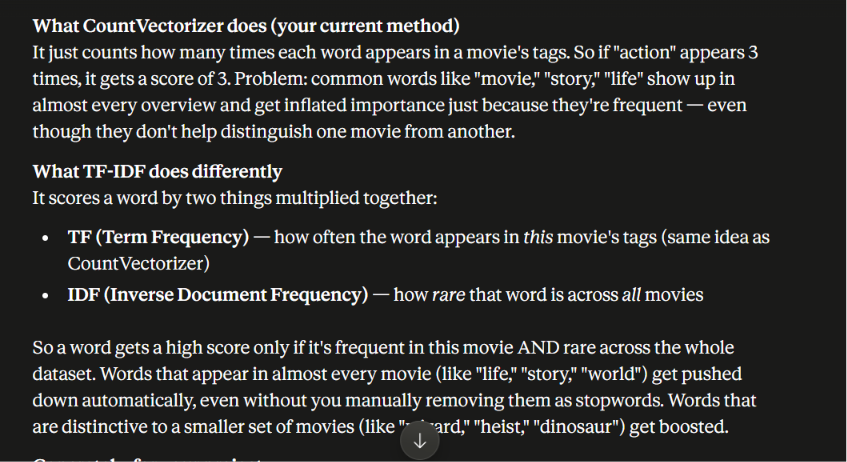

CountVectorizer's `fit_transform()` returns a **sparse matrix**, not a 
regular array — e.g. `X = cv.fit_transform(new_df['tags'])` gives something 
like `<4806x5000 sparse matrix of type numpy.int64>`. It stores only the 
non-zero values, saving memory, since most word-count entries are 0 
(each movie only uses a small fraction of the 5000 vocabulary words).
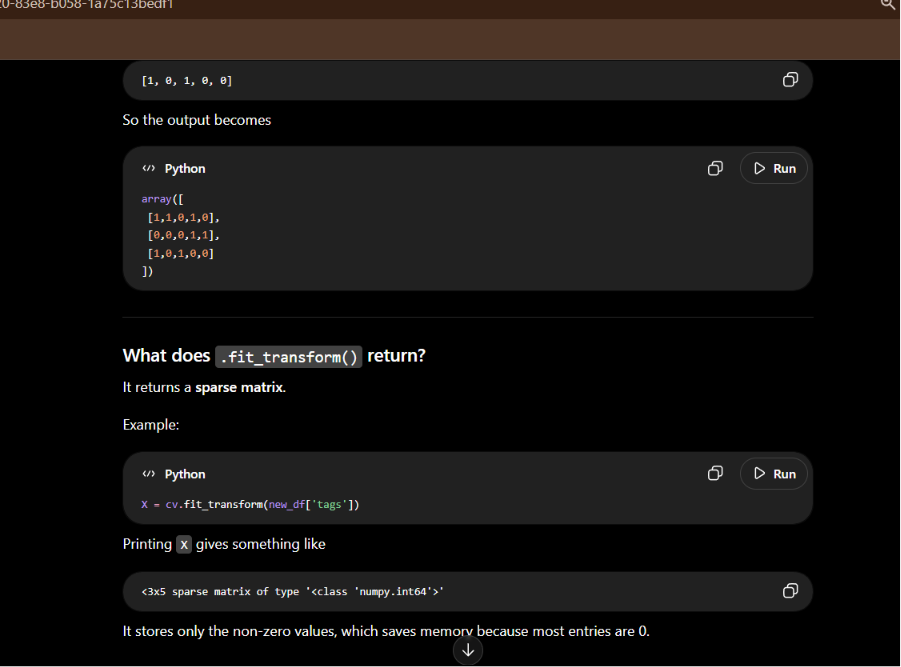
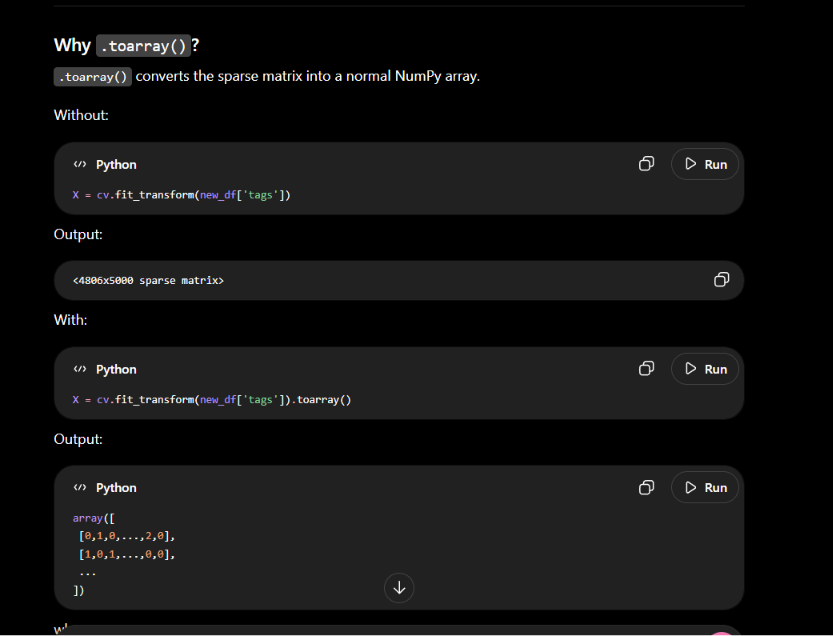

`.toarray()` converts that sparse matrix into a regular NumPy array — 
useful for inspecting values directly or feeding into functions expecting 
a dense array, at the cost of using more memory (since zeros are now 
stored explicitly instead of skipped).

Without `.toarray()`: `<4806x5000 sparse matrix>`
With `.toarray()`: a full `4806x5000` array of 0s and word-counts.

In [37]:
vectors=cv.fit_transform(new_df['tags'])

In [38]:
vectors

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 135132 stored elements and shape (4806, 5000)>

In [39]:
vectors=cv.fit_transform(new_df['tags']).toarray()

In [40]:
vectors

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [41]:
cv.get_feature_names_out()

array(['000', '10', '11', ..., 'zone', 'zoo', 'zooeydeschanel'],
      dtype=object)

In [42]:
cv.get_feature_names_out()[-20:]

array(['youngest', 'youth', 'yuppie', 'zacefron', 'zacharyquinto',
       'zachgalifianakis', 'zachstaenberg', 'zanuck', 'zebra', 'zeus',
       'zhangyimou', 'zhangziyi', 'zoe', 'zoesaldana', 'zombie',
       'zombieapocalypse', 'zombies', 'zone', 'zoo', 'zooeydeschanel'],
      dtype=object)

# now to remove love,loved,loving into one as all same

In [43]:
import nltk

In [44]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [45]:
def stem(text):
    y=[]
   # y=set()
    for i in text.split():
        y.append(ps.stem(i))
    return " ".join(y)

Should you use a set here?

No, not for this movie recommendation project.

Using a set:

❌ Removes duplicate words.
❌ Loses the original word order.

For CountVectorizer, it's better to use a list:

In [46]:
new_df['tags']=new_df['tags'].apply(stem)

/tmp/ipykernel_58/3514595201.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags']=new_df['tags'].apply(stem)


In [47]:
vectors=cv.fit_transform(new_df['tags']).toarray()

In [48]:
cv.get_feature_names_out()[-20:]

array(['youngest', 'youth', 'yuppi', 'zacefron', 'zacharyquinto',
       'zachbraff', 'zachgalifianaki', 'zachstaenberg', 'zanuck', 'zebra',
       'zeu', 'zhangyim', 'zhangziyi', 'zoe', 'zoesaldana', 'zombi',
       'zombieapocalyps', 'zombies', 'zoo', 'zooeydeschanel'],
      dtype=object)

# ## Note: this is unsupervised — no labels, just distance between vectors

 #  we are calculating  cosine distance not euclidian

In [49]:
from sklearn.metrics.pairwise import cosine_similarity 

In [50]:
# import gensim.downloader as api
# import numpy as np

# word_vectors = api.load("glove-wiki-gigaword-100")  # pretrained, 100-dim

# def get_movie_vector(tags_list):
#     vectors = [word_vectors[word] for word in tags_list if word in word_vectors]
#     if not vectors:
#         return np.zeros(100)
#     return np.mean(vectors, axis=0)   # average all word vectors

# new_df['embedding'] = new_df['tags'].apply(get_movie_vector)

# movie_vectors = np.stack(new_df['embedding'].values)
# similarity_embed = cosine_similarity(movie_vectors)

**The core problem with CountVectorizer/TF-IDF:** if one movie's tags 
contain "thriller" and another's contain "suspense," the vectorizer treats 
these as two completely unrelated dimensions — even though they mean almost 
the same thing. Same for "assassin"/"hitman" or "space"/"cosmic." Cosine 
similarity only picks up on literal shared vocabulary, so two thematically 
similar movies described with different words look unrelated to the system.

**What word embeddings are:** a dense numeric vector (typically 100–300 
dimensions) representing a word's *meaning*, learned from huge amounts of 
text — words used in similar contexts end up with similar vectors. Trained 
using models like:
- **Word2Vec** — learns vectors by predicting a word from its surrounding context (or vice versa)
- **GloVe** — learns vectors from global word co-occurrence statistics across a large corpus
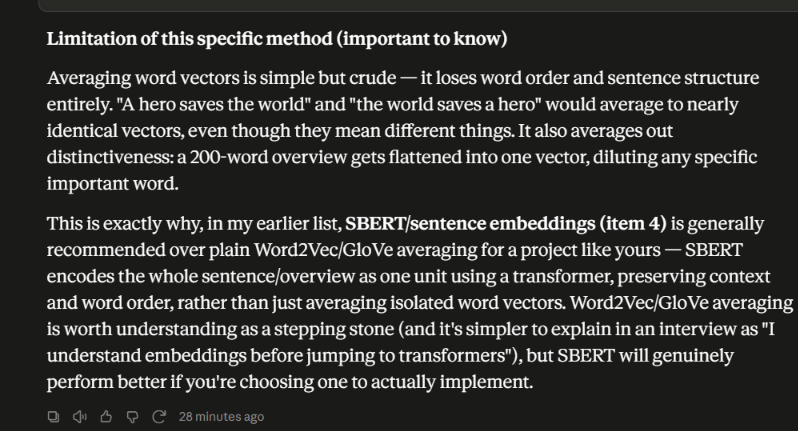
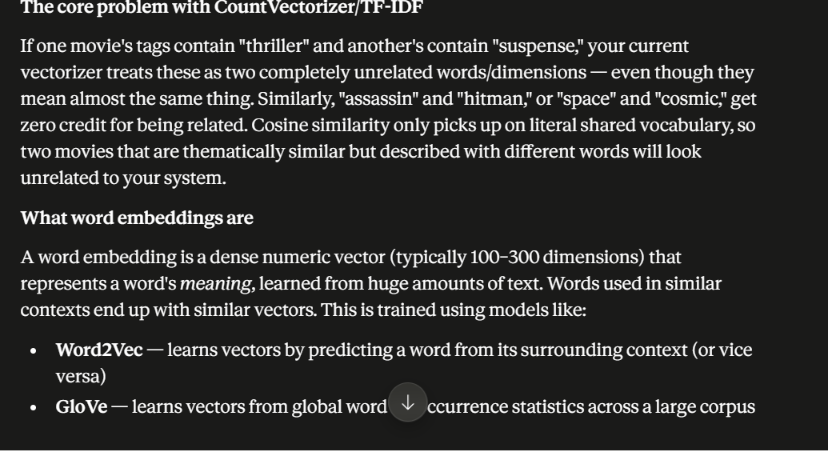

**Limitation of this specific method (word-vector averaging):** simple but 
crude — it loses word order and sentence structure entirely. "A hero saves 
the world" and "the world saves a hero" would average to nearly identical 
vectors, despite meaning different things. It also dilutes distinctiveness: 
a 200-word overview gets flattened into one averaged vector, losing any 
specific important word.

This is why **SBERT/sentence embeddings** are generally preferred over 
plain Word2Vec/GloVe averaging for this kind of project — SBERT encodes 
the whole sentence as one unit using a transformer, preserving context and 
word order, rather than averaging isolated word vectors. Word2Vec/GloVe 
averaging is worth understanding as a stepping stone, but SBERT performs 
better in practice.

In [51]:
similarity=cosine_similarity(vectors)

In [52]:
# similarity

In [53]:
# similarity[0]

# main function

In [54]:
#using enumerate a while sorting indexing gets changed
#sorted(list(enumerate(similarity[0])),reverse=True,key=lambda x:x[1])

In [55]:
def genre_coverage_debug(movie):
    movie_index = new_df[new_df['title'] == movie].index[0]
    movies_list = sorted(list(enumerate(similarity[movie_index])), reverse=True, key=lambda x: x[1])[1:6]
    query_genres = set(new_df.iloc[movie_index]['genres'])
    
    print("Query movie:", movie, "genres:", query_genres)
    for i in movies_list:
        rec_title = new_df.iloc[i[0]]['title']
        rec_genres = set(new_df.iloc[i[0]]['genres'])
        print(rec_title, "→", rec_genres, "overlap:", query_genres & rec_genres)

genre_coverage_debug("Tangled")



Query movie: Tangled genres: {'Animation', 'Family'}
The Princess and the Frog → {'Romance', 'Music', 'Animation', 'Family'} overlap: {'Animation', 'Family'}
Frozen → {'Animation', 'Adventure', 'Family'} overlap: {'Animation', 'Family'}
Bolt → {'Animation', 'Adventure', 'Family', 'Comedy'} overlap: {'Animation', 'Family'}
Out of Inferno → {'Action'} overlap: set()
Animals United → {'Animation', 'Family', 'Comedy'} overlap: {'Animation', 'Family'}


In [56]:
# print(recommend("The Dark Knight"))

5. Collaborative filtering (if you have ratings data)
If TMDB/user rating data is available, matrix factorization (SVD, ALS) or neural collaborative filtering captures "people who liked X also liked Y" — something content-based similarity can never learn, since it only knows about movie attributes, not user behavior.

6. Hybrid system
Combine content-based (your current approach) with collaborative filtering. This is what production systems (Netflix, etc.) actually do — content-based handles cold-start (new movies), collaborative handles taste patterns.

Your current setup has no labels — no target variable (y). Cosine similarity is unsupervised: it just measures distance between vectors. Linear regression, logistic regression, decision trees, RF, XGBoost all need a target to predict. So to use them, you need to convert this into a supervised problem.

. Matrix Factorization for collaborative filtering (unsupervised, if you get rating data)
SVD, ALS (Alternating Least Squares), NMF on the user-item rating matrix — decomposes it into latent user and movie factors without labels. This is the classic unsupervised collaborative filtering method (what old-school Netflix Prize solutions used) — different from the supervised approach I mentioned earlier since there's no explicit "correct answer" being predicted, just latent factor decomposition minimizing reconstruction error.

5. Autoencoders
Neural network learns a compressed latent representation of each movie (or user) by reconstructing input features. Similarity is then computed in the latent space. This is essentially a deep-learning analog of PCA/SVD, and scales better to rich multi-modal features (text + numeric + categorical together).

6. Embedding-based similarity (unsupervised, but neural)
SBERT/Word2Vec embeddings (mentioned earlier) are also unsupervised — no labels needed, just pretrained language representations, then cosine/dot-product similarity on those.

7. Graph-based methods
Build a graph where movies are nodes, edges represent shared cast/genre/keywords. Use Node2Vec / DeepWalk to learn node embeddings, then do similarity search on those embeddings. Captures relational structure that a flat tag vector misses (e.g. actor collaboration networks).

# ## Final approach — SBERT embeddings (replaces bag-of-words above)

## Note: this is unsupervised — no labels, just distance between vectors

# SBERT (Sentence-BERT) fixes the core limitation of both bag-of-words and plain word-embedding averaging: it understands whole sentences, not just individual words in isolation.

In [57]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-MiniLM-L6-v2')  # small, fast, pretrained model

# Encode every movie's tags/overview into a 384-dim vector
embeddings = model.encode(new_df['tags'].tolist(), show_progress_bar=True)

# Compute similarity exactly like before
similarity = cosine_similarity(embeddings)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/151 [00:00<?, ?it/s]

**Trade-offs to know**

- **Speed:** encoding 4800 movies takes a bit longer than CountVectorizer 
  (transformer forward passes vs. simple counting), but it's a one-time cost 
  — encode once, save the vectors, done. Runs fine on CPU for a dataset this 
  size, no GPU needed.
- `all-MiniLM-L6-v2` was chosen specifically because it's small (~80MB) and 
  fast while still being strong. Bigger, more accurate SBERT models exist 
  (e.g. `all-mpnet-base-v2`), but MiniLM is the right trade-off for a 
  project like this that doesn't need production-grade precision.
- **Interpretability drops:** with TF-IDF you could inspect which literal 
  words drove a similarity score. With SBERT, the 384 dimensions are 
  learned and not human-interpretable — you lose that "I can see which 
  words matched" transparency, though the recommendations themselves tend 
  to be qualitatively better.
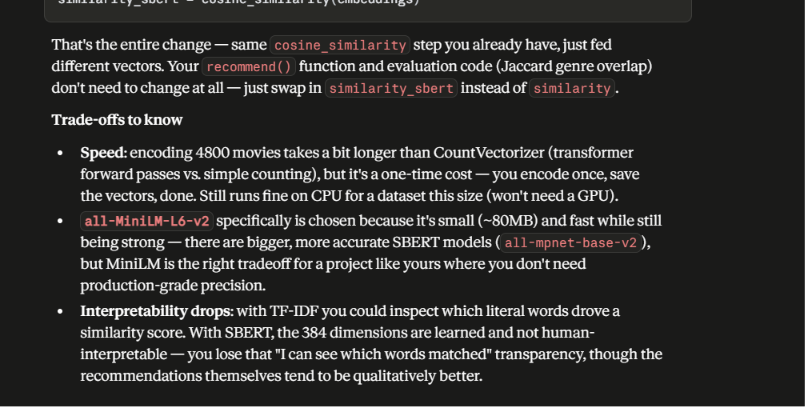

In [58]:
def recommend(movie):
    movie_index=new_df[new_df['title']==movie].index[0]
    movies_list=sorted(list(enumerate(similarity[movie_index])),reverse=True,key=lambda x:x[1])[1:6]

    for i in movies_list:
        print(new_df.iloc[i[0]].title)

In [59]:
recommend("Cars 2")

Cars
Solitary Man
Death Race 2000
Rush
The Lego Movie


In [60]:
# new_df[new_df['title'].str.contains("Harry Potter", case=False)]